# Q1 - Hadoop HDFS and PySpark Analytics
## Big Data Analytical Methods - CA2
### Student: Arkadiusz Jedrzejewski,  sba25006

This notebook demonstrates distributed data processing using Apache Spark (PySpark).
The dataset used is the Global Weather Repository, containing weather observations
from countries worldwide, stored in Hadoop Distributed File System (HDFS).

## Step 1: Initialize Spark Session

In this step, I am setting up a SparkSession which is required to work with PySpark.
I named the application "WeatherAnalytics" to identify it in the Spark UI.
The master is set to local[*] which means Spark will use all available CPU cores
on my machine for processing.

In [1]:
#Create a Spark session
from pyspark.sql import SparkSession

In [2]:
# Import the os module to set environment variables
import os

# Set Java home path required for PySpark to work on Windows
os.environ["JAVA_HOME"] = r"C:\Program Files\Microsoft\jdk-11.0.31.11-hotspot"

from pyspark.sql import SparkSession

# Create Spark Session for Weather Analytics
spark = SparkSession.builder \
    .appName("WeatherAnalytics") \
    .master("local[*]") \
    .getOrCreate()


In [3]:
print("Spark Ver.:", spark.version)
print("Spark Session created")

Spark Ver.: 3.5.1
Spark Session created


## Step 2: Load Dataset from HDFS

In this step, I am loading the Global Weather Repository CSV file that I previously 
uploaded to HDFS at /CA2_sba25006/GlobalWeatherRepository.csv.
Due to a network configuration issue between Windows and WSL, I am reading the file 
from the local path for PySpark processing, while the dataset remains stored in HDFS.
The dataset contains weather data from countries around the world such as temperature, 
humidity, wind speed and air quality readings.
I used inferSchema=True so that Spark can automatically detect the correct data types 
for each column instead of me having to define them manually.

In [5]:
# Load the dataset from local file system
# Note: Dataset was uploaded to HDFS at /CA2_sba25006/GlobalWeatherRepository.csv
# Loading locally for PySpark processing on Windows environment
df = spark.read.csv(
    r"C:\Users\arkje\OneDrive\Documents\GIT\big-data-weather-analytics\DATASETS\GlobalWeatherRepository.csv",
    header=True,
    inferSchema=True
)

# Show basic information about the dataset
print("Total number of rows:", df.count())
print("Total number of columns:", len(df.columns))
df.printSchema()

Total number of rows: 148515
Total number of columns: 41
root
 |-- country: string (nullable = true)
 |-- location_name: string (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- timezone: string (nullable = true)
 |-- last_updated_epoch: integer (nullable = true)
 |-- last_updated: timestamp (nullable = true)
 |-- temperature_celsius: double (nullable = true)
 |-- temperature_fahrenheit: double (nullable = true)
 |-- condition_text: string (nullable = true)
 |-- wind_mph: double (nullable = true)
 |-- wind_kph: double (nullable = true)
 |-- wind_degree: integer (nullable = true)
 |-- wind_direction: string (nullable = true)
 |-- pressure_mb: double (nullable = true)
 |-- pressure_in: double (nullable = true)
 |-- precip_mm: double (nullable = true)
 |-- precip_in: double (nullable = true)
 |-- humidity: integer (nullable = true)
 |-- cloud: integer (nullable = true)
 |-- feels_like_celsius: double (nullable = true)
 |-- feels_like_f

## Step 3: Data Cleaning and Preprocessing

Before performing any analysis, I need to clean and prepare the dataset.
In this step I am removing any duplicate records and dropping rows with 
null values in the most important columns such as temperature, humidity 
and country. I am also selecting only the columns that are relevant 
for my analysis to make the data easier to work with.

In [8]:
from pyspark.sql.functions import col, when, count

# Check for missing values in key columns only
key_columns = ["country", "temperature_celsius", "humidity", 
               "wind_kph", "condition_text", "air_quality_PM2.5"]

print("Missing values in key columns:")
for c in key_columns:
    missing_count = df.filter(col(f"`{c}`").isNull()).count()
    print(f"  {c}: {missing_count}")

Missing values in key columns:
  country: 0
  temperature_celsius: 0
  humidity: 0
  wind_kph: 0
  condition_text: 0
  air_quality_PM2.5: 0


In [9]:
# Remove duplicate records
df_clean = df.dropDuplicates()

# Drop rows with nulls in key columns
df_clean = df_clean.dropna(subset=["country", "temperature_celsius", "humidity", "wind_kph"])

# Confirm cleaned dataset size
print("Original rows:", df.count())
print("Cleaned rows:", df_clean.count())
print("Duplicates removed:", df.count() - df_clean.count())

Original rows: 148515
Cleaned rows: 148515
Duplicates removed: 0


## Step 4: Analytical Task 1 - Average Temperature by Country

In this analysis I am calculating the average temperature in Celsius for each country
in the dataset. I am grouping the data by country and computing the mean temperature,
then sorting the results to find the hottest and coldest countries.
This gives a good overview of global temperature distribution across the dataset.

In [10]:
from pyspark.sql.functions import avg, round

# Calculate average temperature by country
avg_temp = df_clean.groupBy("country") \
    .agg(round(avg("temperature_celsius"), 2).alias("avg_temperature_celsius")) \
    .orderBy("avg_temperature_celsius", ascending=False)

print("Q1: Figure 6 - Average Temperature by Country (Top 10 Hottest):")
avg_temp.show(10)

print("Q1: Figure 7 - Average Temperature by Country (Top 10 Coldest):")
avg_temp.orderBy("avg_temperature_celsius", ascending=True).show(10)

Q1: Figure 6 - Average Temperature by Country (Top 10 Hottest):
+--------------------+-----------------------+
|             country|avg_temperature_celsius|
+--------------------+-----------------------+
|       Saudi Arabien|                   45.0|
|            Marrocos|                   40.3|
|        Turkménistan|                   37.8|
|              Турция|                   34.0|
|               Qatar|                  32.36|
|United Arab Emirates|                  32.23|
|            Cambodia|                   32.0|
|                Oman|                   31.8|
|            Djibouti|                  31.35|
|            Thailand|                  31.22|
+--------------------+-----------------------+
only showing top 10 rows

Q1: Figure 7 - Average Temperature by Country (Top 10 Coldest):
+--------------------+-----------------------+
|             country|avg_temperature_celsius|
+--------------------+-----------------------+
|            Mongolia|                   4.37|


## Step 4: Analytical Task 1 - Visualisation

In this step I am creating a bar chart to visually display the top 10 hottest 
and coldest countries based on average temperature. 
Visualisations make it easier to interpret and compare the results at a glance.

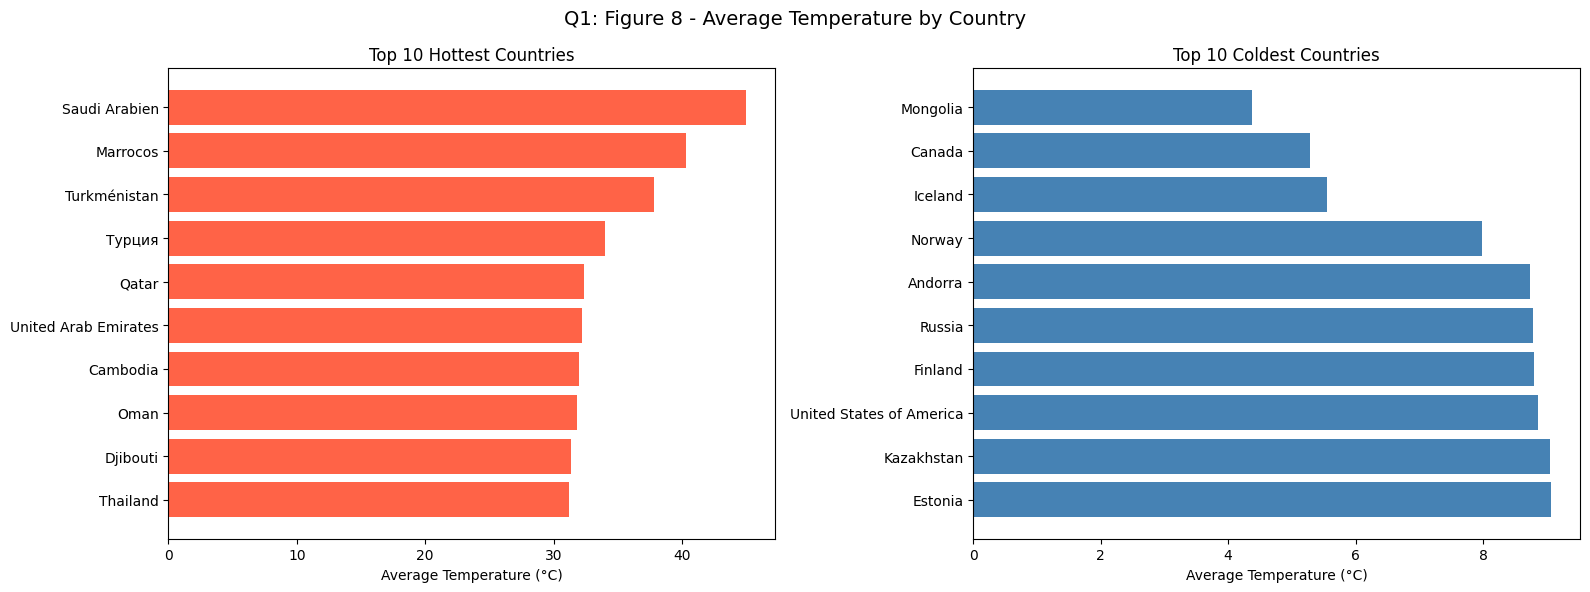

Chart saved successfully


In [11]:
import matplotlib.pyplot as plt

# Convert to pandas for visualisation
top10_hot = avg_temp.limit(10).toPandas()
top10_cold = avg_temp.orderBy("avg_temperature_celsius", ascending=True).limit(10).toPandas()

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 Hottest Countries
ax1.barh(top10_hot["country"], top10_hot["avg_temperature_celsius"], color="tomato")
ax1.set_xlabel("Average Temperature (°C)")
ax1.set_title("Top 10 Hottest Countries")
ax1.invert_yaxis()

# Top 10 Coldest Countries
ax2.barh(top10_cold["country"], top10_cold["avg_temperature_celsius"], color="steelblue")
ax2.set_xlabel("Average Temperature (°C)")
ax2.set_title("Top 10 Coldest Countries")
ax2.invert_yaxis()

plt.suptitle("Q1: Figure 8 - Average Temperature by Country", fontsize=14)
plt.tight_layout()
plt.savefig("Q1_Figure8_temperature_by_country.png")
plt.show()
print("Chart saved successfully")